In [2]:
from pybaseball import statcast
import pandas as pd
import numpy as np

In [4]:
from pybaseball_data_handler import fetch_statcast_to_parquet, get_team_vector_from_parquet
import pyarrow.parquet as pq 

In [6]:
schema = pq.read_schema('data/full_2025_season.parquet')
print(schema.names)
pf = pq.ParquetFile('data/full_2025_season.parquet')

['pitch_type', 'game_date', 'release_speed', 'release_pos_x', 'release_pos_z', 'player_name', 'batter', 'pitcher', 'events', 'description', 'spin_dir', 'spin_rate_deprecated', 'break_angle_deprecated', 'break_length_deprecated', 'zone', 'des', 'game_type', 'stand', 'p_throws', 'home_team', 'away_team', 'type', 'hit_location', 'bb_type', 'balls', 'strikes', 'game_year', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'on_3b', 'on_2b', 'on_1b', 'outs_when_up', 'inning', 'inning_topbot', 'hc_x', 'hc_y', 'tfs_deprecated', 'tfs_zulu_deprecated', 'umpire', 'sv_id', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az', 'sz_top', 'sz_bot', 'hit_distance_sc', 'launch_speed', 'launch_angle', 'effective_speed', 'release_spin_rate', 'release_extension', 'game_pk', 'fielder_2', 'fielder_3', 'fielder_4', 'fielder_5', 'fielder_6', 'fielder_7', 'fielder_8', 'fielder_9', 'release_pos_y', 'estimated_ba_using_speedangle', 'estimated_woba_using_speedangle', 'woba_value', 'woba_denom', 'babip_value', 'iso_value', 'launch_speed_a

In [ ]:
my_df = pd.read_csv("data")

In [19]:
import random
import pandas as pd

class InningOutcomeDistribution:
    def __init__(self, team_abbr: str, data_source: str, start_date=None, end_date=None):
        # 1. Load the data simply
        df = pd.read_parquet(data_source, engine='pyarrow')
        
        # 2. Clean the team names and dates immediately
        team_abbr = team_abbr.upper()
        df['game_date'] = pd.to_datetime(df['game_date'])
        
        # 3. Apply Filters in standard Pandas (more reliable than pyarrow filters)
        if start_date:
            df = df[df['game_date'] >= pd.to_datetime(start_date)]
        if end_date:
            df = df[df['game_date'] <= pd.to_datetime(end_date)]
            
        # 4. Filter for only this team's OFFENSE
        # (Home team in Bottom of inning OR Away team in Top of inning)
        is_team = (df['home_team'] == team_abbr) | (df['away_team'] == team_abbr)
        is_event = df['events'].notna()
        
        team_df = df[is_team & is_event].copy()
        
        # Correct for offense: only keep rows where the specified team was batting
        team_df = team_df[
            ((team_df['home_team'] == team_abbr) & (team_df['inning_topbot'] == 'Bot')) |
            ((team_df['away_team'] == team_abbr) & (team_df['inning_topbot'] == 'Top'))
        ]

        if team_df.empty:
            # DEBUG: Tell us what IS in the file if we found nothing
            available_teams = df['home_team'].unique()
            available_dates = f"{df['game_date'].min()} to {df['game_date'].max()}"
            raise ValueError(f"No data for {team_abbr}. File has teams {available_teams} and dates {available_dates}")

        # 5. Calculate probabilities
        total = len(team_df)
        counts = team_df['events'].value_counts()
        
        self.team = team_abbr
        self.probabilities = {
            '1B': counts.get('single', 0) / total,
            '2B': counts.get('double', 0) / total,
            '3B': counts.get('triple', 0) / total,
            'HR': counts.get('home_run', 0) / total,
            'WALK': (counts.get('walk', 0) + counts.get('hit_by_pitch', 0)) / total,
        }
        self.probabilities['OUT'] = 1 - sum(self.probabilities.values())
        
        self._outcomes = list(self.probabilities.keys())
        self._weights = list(self.probabilities.values())

    def sample(self):
        return random.choices(self._outcomes, weights=self._weights, k=1)[0]

    def __repr__(self):
        return f"<OutcomeDist {self.team}: HR={self.probabilities['HR']:.4f}>"

In [ ]:
lad_dist = InningOutcomeDistribution("LAD", "data/full_2025_season.parquet", "2025-01-14", "2025-08-15")
nyy_dist = InningOutcomeDistribution("NYY", "data/full_2025_season.parquet", "2025-01-14", "2025-08-15")


In [30]:
col_dist = InningOutcomeDistribution("COL", "data/full_2025_season.parquet", "2025-01-14", "2025-08-15")

In [21]:
print("NYY:", nyy_dist)
print("LAD:", lad_dist)

NYY: <OutcomeDist NYY: HR=0.0410>
LAD: <OutcomeDist LAD: HR=0.0383>


In [22]:
class InningState:
    def __init__(self):
        self.outs = 0
        self.bases = [0,0,0]
        self.runs = 0
    def is_over(self):
        return self.outs >= 3
    def get_id(self):
        return (self.outs, self.bases)
    @property
    def key(self):
        if self.outs >= 3:
            return (3, 0, 0, 0)
        return (self.outs, *self.bases)


In [23]:
import random
from typing import List, Tuple, Optional

def get_outcome(p_out:int, p_walk:int, p_single:int, p_double:int, p_triple:int, p_hr:int):
    events = ['OUT', 'WALK', '1B', '2B', '3B', 'HR']
    weights = [p_out, p_walk, p_single, p_double, p_triple, p_hr]
    return random.choice(events, weights=weights)[0]

def transition(outs, bases, outcome) -> Tuple[int, List[int], int]:
    
    new_bases = []
    runs_on_play = 0

    match outcome:
        case 'WALK':
            new_bases, runs_on_play = handle_walk(bases)
        case '1B':
            new_bases, runs_on_play = advance_bases(bases, 1)
            pass
        case '2B':
            new_bases, runs_on_play = advance_bases(bases, 2)
            pass
        case '3B':
            new_bases, runs_on_play = advance_bases(bases, 3)
            pass
        case 'HR':
            new_bases, runs_on_play = [0,0,0], sum(bases) + 1
        case 'OUT':
            outs += 1
            new_bases, runs_on_play = bases, 0

    return outs, new_bases, runs_on_play

def advance_bases(bases, bases_to_move):

    # Format: (Current_Bases_Tuple, Hit_Type): (New_Bases_Tuple, Runs_Scored)
    # Lookup table 
    HIT_LUT = {
        # --- NO RUNNERS ---
        ((0,0,0), 1): ((1,0,0), 0), ((0,0,0), 2): ((0,1,0), 0),
        ((0,0,0), 3): ((0,0,1), 0), ((0,0,0), 4): ((0,0,0), 1),

        # --- RUNNER ON 1ST ---
        ((1,0,0), 1): ((1,1,0), 0), ((1,0,0), 2): ((0,1,1), 0),
        ((1,0,0), 3): ((0,0,1), 1), ((1,0,0), 4): ((0,0,0), 2),

        # --- RUNNER ON 2ND ---
        ((0,1,0), 1): ((1,0,1), 0), ((0,1,0), 2): ((0,1,0), 1),
        ((0,1,0), 3): ((0,0,1), 1), ((0,1,0), 4): ((0,0,0), 2),

        # --- RUNNER ON 3RD ---
        ((0,0,1), 1): ((1,0,0), 1), ((0,0,1), 2): ((0,1,0), 1),
        ((0,0,1), 3): ((0,0,1), 1), ((0,0,1), 4): ((0,0,0), 2),

        # --- 1ST AND 2ND ---
        ((1,1,0), 1): ((1,1,1), 0), ((1,1,0), 2): ((0,1,1), 1),
        ((1,1,0), 3): ((0,0,1), 2), ((1,1,0), 4): ((0,0,0), 3),

        # --- 1ST AND 3RD ---
        ((1,0,1), 1): ((1,1,0), 1), ((1,0,1), 2): ((0,1,1), 1),
        ((1,0,1), 3): ((0,0,1), 2), ((1,0,1), 4): ((0,0,0), 3),

        # --- 2ND AND 3RD ---
        ((0,1,1), 1): ((1,0,1), 1), ((0,1,1), 2): ((0,1,0), 2),
        ((0,1,1), 3): ((0,0,1), 2), ((0,1,1), 4): ((0,0,0), 3),

        # --- BASES LOADED ---
        ((1,1,1), 1): ((1,1,1), 1), ((1,1,1), 2): ((0,1,1), 2),
        ((1,1,1), 3): ((0,0,1), 3), ((1,1,1), 4): ((0,0,0), 4),
    }
    
    return HIT_LUT[tuple(bases), bases_to_move]


def handle_walk(bases):
    new_bases = list(bases)
    runs = 0
    
    # If 1st is empty, batter just takes it.
    if not bases[0]:
        new_bases[0] = 1
    # If 1st is full, we have to check 2nd, then 3rd...
    elif not bases[1]:
        new_bases[1] = 1
    elif not bases[2]:
        new_bases[2] = 1
    else:
        # Bases were loaded
        runs = 1
        
    return new_bases, runs


In [25]:
def get_next_state_key(outs, bases, outcome):

    outs, bases, runs_in_play = transition(outs, bases, outcome)
    
    if outs >= 3:
        return (3, 0, 0, 0), 0
    
    return (outs, *bases), runs_in_play

def simulate_inning(dist:InningOutcomeDistribution):
    state = (0,0,0,0)
    inning_runs = 0

    while state[0] < 3:
        outcome = dist.sample()
        state, runs_in_play = get_next_state_key(state[0], state[1:4], outcome)
        inning_runs += runs_in_play
    
    return inning_runs

def simulate_game(home_team:str, away_team:str, path:str, n:int):
    print("Generating Distributions")
    home_dist = InningOutcomeDistribution(home_team, path)
    away_dist = InningOutcomeDistribution(away_team, path)
    simulated_results = dict()

    print("Simulating results:")
    for i in range(n):
        game_finished = False
        home_run_score = 0
        away_run_score = 0
        inning_num = 0
        while(not game_finished):
            inning_num += 1
            runs_scored_home = simulate_inning(home_dist)
            runs_scored_away = simulate_inning(away_dist)
            home_run_score += runs_scored_home
            away_run_score += runs_scored_away
            
            if(inning_num >= 9 and home_run_score != away_run_score):
                game_finished = True
                result = (home_run_score, away_run_score)
                if not result in simulated_results:
                    simulated_results[result] = 0
                simulated_results[result] += 1
    print("Simulation Done.")

    return simulated_results

def simulate_game(home_team:str, away_team:str, home_dist:InningOutcomeDistribution, away_dist:InningOutcomeDistribution, n:int):
    print("Generating Distributions")
    simulated_results = dict()

    print("Simulating results:")
    for i in range(n):
        game_finished = False
        home_run_score = 0
        away_run_score = 0
        inning_num = 0
        while(not game_finished):
            inning_num += 1
            runs_scored_home = simulate_inning(home_dist)
            runs_scored_away = simulate_inning(away_dist)
            home_run_score += runs_scored_home
            away_run_score += runs_scored_away
            
            if(inning_num >= 9 and home_run_score != away_run_score):
                game_finished = True
                result = (home_run_score, away_run_score)
                if not result in simulated_results:
                    simulated_results[result] = 0
                simulated_results[result] += 1
    print("Simulation Done.")

    return simulated_results
        



In [31]:
simulated_results = simulate_game("LAD", "COL", lad_dist, col_dist, 10000)

Generating Distributions
Simulating results:
Simulation Done.


In [32]:
simulated_results

{(0, 4): 105,
 (1, 2): 274,
 (4, 6): 83,
 (13, 7): 2,
 (4, 1): 250,
 (7, 9): 12,
 (3, 2): 290,
 (0, 3): 147,
 (9, 3): 46,
 (0, 5): 91,
 (8, 3): 76,
 (2, 4): 188,
 (4, 7): 56,
 (2, 1): 270,
 (8, 4): 62,
 (7, 5): 65,
 (2, 7): 58,
 (5, 8): 26,
 (4, 2): 241,
 (1, 5): 116,
 (1, 3): 212,
 (7, 0): 107,
 (11, 0): 21,
 (5, 6): 93,
 (8, 5): 62,
 (12, 6): 3,
 (9, 8): 7,
 (12, 0): 11,
 (4, 0): 181,
 (1, 11): 7,
 (6, 1): 140,
 (5, 3): 185,
 (0, 2): 201,
 (7, 6): 45,
 (6, 3): 141,
 (8, 7): 31,
 (4, 5): 142,
 (2, 8): 32,
 (11, 6): 10,
 (2, 5): 149,
 (2, 0): 259,
 (0, 7): 44,
 (3, 0): 235,
 (5, 0): 142,
 (9, 5): 29,
 (6, 5): 83,
 (9, 2): 58,
 (1, 4): 133,
 (3, 1): 303,
 (5, 4): 141,
 (3, 5): 146,
 (7, 4): 78,
 (13, 0): 6,
 (5, 2): 224,
 (1, 0): 234,
 (0, 1): 189,
 (6, 4): 98,
 (8, 0): 64,
 (7, 3): 85,
 (5, 1): 197,
 (6, 2): 149,
 (6, 0): 125,
 (12, 4): 9,
 (13, 5): 3,
 (9, 6): 19,
 (0, 6): 55,
 (3, 11): 7,
 (4, 3): 243,
 (8, 2): 77,
 (4, 10): 8,
 (2, 3): 268,
 (3, 7): 57,
 (3, 9): 29,
 (10, 0): 39,
 (

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

def summarize_sim(results_dict, home_name="NYY", away_name="LAD"):
    data = []
    for (h, a), freq in results_dict.items():
        data.append({"Home": h, "Away": a, "Count": freq})
    df = pd.DataFrame(data)

    total_games = df['Count'].sum()
    home_wins = df[df['Home'] > df['Away']]['Count'].sum()
    away_wins = df[df['Away'] > df['Home']]['Count'].sum()
    
    avg_h = (df['Home'] * df['Count']).sum() / total_games
    avg_a = (df['Away'] * df['Count']).sum() / total_games

    print(f"--- {home_name} vs {away_name} Analysis ---")
    print(f"Total Games: {total_games}")
    print(f"{home_name} Win Prob: {home_wins/total_games:.2%}")
    print(f"{away_name} Win Prob: {away_wins/total_games:.2%}")
    print(f"Expected Score: {home_name} {avg_h:.1f} - {away_name} {avg_a:.1f}")

    # create heatmap
    pivot = df.pivot(index="Home", columns="Away", values="Count").fillna(0)
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
    plt.title(f"Score Probability Matrix: {home_name} vs {away_name}")
    plt.show()

--- LAD vs COL Analysis ---
Total Games: 10000
LAD Win Prob: 59.90%
COL Win Prob: 40.10%
Expected Score: LAD 4.1 - COL 3.1


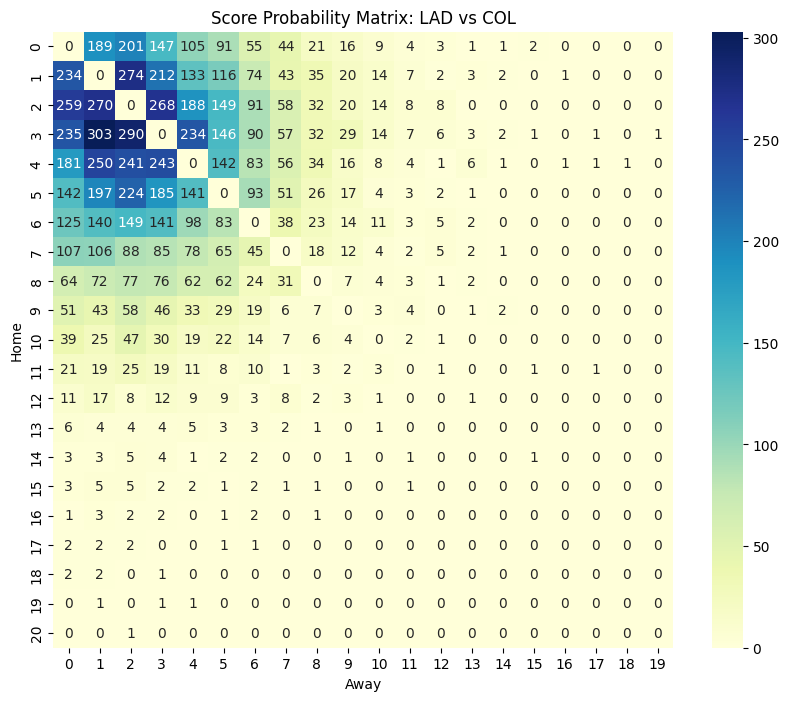

In [36]:
summarize_sim(results_dict=simulated_results, home_name="LAD", away_name="COL")

In [35]:
def get_bases_from_int(n):
    # Returns [1st, 2nd, 3rd] as 0s or 1s
    return [(n >> i) & 1 for i in range(3)]

for hit in [1, 2, 3]:
    print(f"\n--- TESTING {hit}B ---")
    for base_config in range(8):
        bases = get_bases_from_int(base_config)
        new_bases, runs = advance_bases(bases, hit)
        
        # Check if it makes sense
        # e.g., On a 3B (Triple), new_bases MUST be [0, 0, 1]
        print(f"Bases: {bases} -> {new_bases} | Runs: {runs}")


--- TESTING 1B ---
Bases: [0, 0, 0] -> (1, 0, 0) | Runs: 0
Bases: [1, 0, 0] -> (1, 1, 0) | Runs: 0
Bases: [0, 1, 0] -> (1, 0, 1) | Runs: 0
Bases: [1, 1, 0] -> (1, 1, 1) | Runs: 0
Bases: [0, 0, 1] -> (1, 0, 0) | Runs: 1
Bases: [1, 0, 1] -> (1, 1, 0) | Runs: 1
Bases: [0, 1, 1] -> (1, 0, 1) | Runs: 1
Bases: [1, 1, 1] -> (1, 1, 1) | Runs: 1

--- TESTING 2B ---
Bases: [0, 0, 0] -> (0, 1, 0) | Runs: 0
Bases: [1, 0, 0] -> (0, 1, 1) | Runs: 0
Bases: [0, 1, 0] -> (0, 1, 0) | Runs: 1
Bases: [1, 1, 0] -> (0, 1, 1) | Runs: 1
Bases: [0, 0, 1] -> (0, 1, 0) | Runs: 1
Bases: [1, 0, 1] -> (0, 1, 1) | Runs: 1
Bases: [0, 1, 1] -> (0, 1, 0) | Runs: 2
Bases: [1, 1, 1] -> (0, 1, 1) | Runs: 2

--- TESTING 3B ---
Bases: [0, 0, 0] -> (0, 0, 1) | Runs: 0
Bases: [1, 0, 0] -> (0, 0, 1) | Runs: 1
Bases: [0, 1, 0] -> (0, 0, 1) | Runs: 1
Bases: [1, 1, 0] -> (0, 0, 1) | Runs: 2
Bases: [0, 0, 1] -> (0, 0, 1) | Runs: 1
Bases: [1, 0, 1] -> (0, 0, 1) | Runs: 2
Bases: [0, 1, 1] -> (0, 0, 1) | Runs: 2
Bases: [1, 1, 1] -> 